# Sensor Air Quality Index (AQI) calculation for the past 1h, 8h or 24h

#### Before starting run the next cell to install the required Python libraries first required to run the code:

In [ ]:
# run this cell once only if you need to install the libraries
!pip install requests pandas plotly matplotlib seaborn
!pip install --upgrade pip

### **Step 1: Get Sensor Data: Request your sensor device last observations from the database (API).**
#### You need to run the next cell and you will be asked to:
- Enter Smart Citizen device ID:
- Select the time to use to calculate the AQI: "1 - last 1 hour"; "2 - last 8 hours";  "3 - last 24 hours"
- Select the Observed Property: "1 - Particle Matter PM 2.5"; "2 - Carbon Dioxide"

Enter your Smart Citizen Device ID:  16769



Select the time range to retrieve data:
1 - Last 1 hour
2 - Last 8 hours
3 - Last 24 hours


Enter 1, 2, or 3:  1



Select the observed property:
1 - PM 2.5 (Particulate Matter)
2 - CO₂ (Carbon Dioxide)


Enter 1 or 2:  2



Fetching data from: https://api.smartcitizen.me/v0/devices/16769/readings?sensor_id=112&rollup=5m&from=2025-06-25T13:43:45&to=2025-06-25T14:43:45


,datetime,value
0,2025-06-25 14:40:04+00:00,1495.0
1,2025-06-25 14:35:04+00:00,1495.0
2,2025-06-25 14:30:04+00:00,1495.8
3,2025-06-25 14:25:04+00:00,1497.6
4,2025-06-25 14:20:04+00:00,1474.8
5,2025-06-25 14:15:04+00:00,1507.8
6,2025-06-25 14:10:04+00:00,1519.6
7,2025-06-25 14:05:04+00:00,1533.8
8,2025-06-25 14:00:04+00:00,1543.4
9,2025-06-25 13:55:04+00:00,1554.6


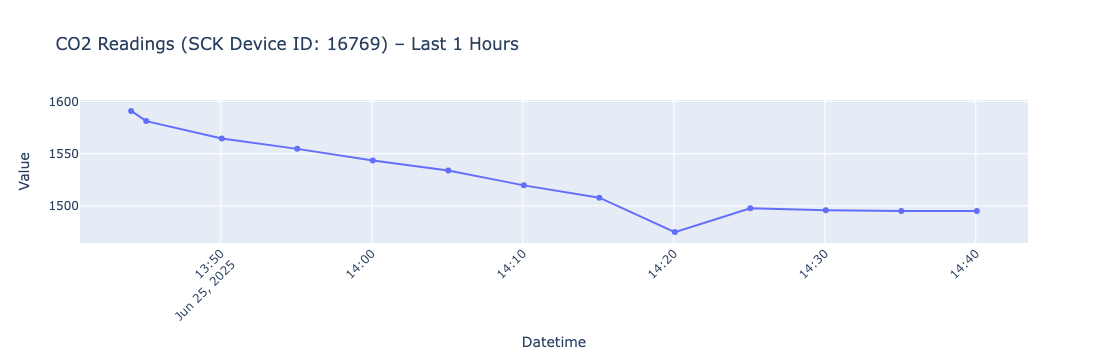

In [3]:
# Run this cell to be asked for your input below
import requests
import datetime
import pandas as pd
import plotly.express as px
import seaborn as sns
from IPython.display import display, HTML

def get_sensor_data():
    try:
        # 1. Device ID input
        device_id = input("Enter your Smart Citizen Device ID: ").strip()
        # 17277 - Blackrock, Dublin, Ireland
        # 17183 - Dalkey, Ireland
        if not device_id:
            raise ValueError("Device ID cannot be empty.")
        
        # 2. Time range selection
        print("\nSelect the time range to retrieve data:")
        print("1 - Last 1 hour")
        print("2 - Last 8 hours")
        print("3 - Last 24 hours")
        time_choice = input("Enter 1, 2, or 3: ").strip()
        
        time_mapping = {"1": 1, "2": 8, "3": 24}
        hours_back = time_mapping.get(time_choice)
        if not hours_back:
            raise ValueError("Invalid choice for time range. Please enter 1, 2, or 3.")
        
        # 3. Observed property selection
        print("\nSelect the observed property:")
        print("1 - PM 2.5 (Particulate Matter)")
        print("2 - CO₂ (Carbon Dioxide)")
        sensor_choice = input("Enter 1 or 2: ").strip()
        
        sensor_mapping = {
            "1": 87,  # PM2.5 on SmartCitizen platform
            "2": 112  # CO2 (eCO2) on SmartCitizen platform
        }
        observed_property_mapping = {"1": "PM2.5", "2": "CO2"}
        sensor_id = sensor_mapping.get(sensor_choice)
        observed_property_name = observed_property_mapping.get(sensor_choice)
        if not sensor_id or not observed_property_name:
            raise ValueError("Invalid choice for observed property. Please enter 1 or 2.")
        
        # 4. Define time window
        now = datetime.datetime.utcnow()
        from_time = now - datetime.timedelta(hours=hours_back)
        from_time_str = from_time.strftime('%Y-%m-%dT%H:%M:%S')
        to_time_str = now.strftime('%Y-%m-%dT%H:%M:%S')
        time_interval_str = f"{hours_back}h"

        # 5. Fetch data from API
        api_url = (
            f"https://api.smartcitizen.me/v0/devices/{device_id}/readings?"
            f"sensor_id={sensor_id}&rollup=5m&from={from_time_str}&to={to_time_str}"
        )
        print(f"\nFetching data from: {api_url}")
        response = requests.get(api_url)
        response.raise_for_status()
        data = response.json()
        
        # 6. Parse readings
        observations = data.get("readings", [])
        if not observations:
            raise ValueError("No observations found for the selected parameters.")
        
        df = pd.DataFrame(observations, columns=["datetime", "value"])
        df["datetime"] = pd.to_datetime(df["datetime"])
        observations_avg = df["value"].mean()

        # 7. Display table
        sns.set_style("whitegrid")
        display(HTML(f"""
        <style>
            .table-container {{
                width: 100%;
                display: flex;
                justify-content: center;
            }}
            .table-striped {{
                width: 100%;
                max-width: 100%;
            }}
        </style>
        <div class='table-container'>
            {df.to_html(classes='table table-striped', escape=False, border=0)}
        </div>
        """))

        # 8. Plot chart
        # 8. Plot chart
        fig = px.line(df, x='datetime', y='value',
                      title=f"{observed_property_name} Readings (SCK Device ID: {device_id}) – Last {hours_back} Hours",
                      markers=True)
        fig.update_xaxes(title_text='Datetime', tickangle=-45)
        fig.update_yaxes(title_text='Value')
        fig.show()

        # 9. Display average
        display(HTML(
            f"<h3>Average {observed_property_name} value over the last {time_interval_str}: "
            f"<strong>{observations_avg:.2f}</strong></h3>"
        ))

        return df, observed_property_name, observations_avg, time_interval_str, from_time_str, to_time_str

    except requests.exceptions.RequestException as e:
        print(f"\nNetwork error: {e}")
    except ValueError as e:
        print(f"\nInput error: {e}")
    except Exception as e:
        print(f"\nUnexpected error: {e}")

    return None, None, None, None, None, None

# Run the function
readings_df, observed_property_name, observations_avg, time_interval_str, from_time_str, to_time_str = get_sensor_data()

### **Step 2: Air Quality Index calculation using the sensor observations retrieved before.**
#### You need to run the next cell, you will be asked to:
- Select the guideline you want to use for the AQI standard: "1 - US EPA"; "2 - TwinAIR project AQI"

In [4]:
import bisect
import logging
from functools import lru_cache
from typing import Dict, List, TypedDict
import numpy as np
import pandas as pd
from IPython.display import display, HTML
logger = logging.getLogger("notebook.aqi")

# ------------------------------------------------------------------ helpers
def _normalise(name: str) -> str:
    """Bring user / API pollutant names to the canonical KEYS used in the tables."""
    return (
        name.replace("₃", "3")
            .replace("₂", "2")
            .replace("PM 2.5", "PM2.5")  # Smart-Citizen label → canonical
    )

# ------------------------------------------------------------------ constants
class Band(TypedDict):
    rating: str
    index: int
    low: float
    high: float
    rating_color: str


def _build_table(raw: Dict[str, List]) -> Dict[str, List[Band]]:
    pollutants = [k.split("_low")[0] for k in raw if k.endswith("_low")]
    table: Dict[str, List[Band]] = {p: [] for p in pollutants}

    for row_idx in range(len(raw["Rating"])):
        common = {
            "rating": raw["Rating"][row_idx],
            "rating_color": raw["Rating_colors"][row_idx],
            "index": raw["Index"][row_idx] if "Index" in raw else raw["Index_high"][row_idx],
        }
        for pollutant in pollutants:
            table[pollutant].append(
                Band(
                    **common,
                    low=float(raw[f"{pollutant}_low"][row_idx]),
                    high=float(raw[f"{pollutant}_high"][row_idx]),
                )
            )

    # ascending order
    for lst in table.values():
        lst.sort(key=lambda b: b["low"])
    return table



USEPA_RAW = {
    "Rating": ["Excellent", "Fine", "Moderate", "Poor", "Very Poor", "Severe"],
    "Index": [1, 2, 3, 4, 5, 6],
    "AQI_value_low": [0, 51, 101, 151, 201, 301],
    "AQI_value_high": [50, 100, 150, 200, 300, 400],
    "CO2_low": [250, 401, 1001, 1501, 2001, 5000],
    "CO2_high": [400, 1000, 1500, 2000, 5000, float("inf")],
    "TVOC_low": [0, 251, 501, 751, 1001, 3000],
    "TVOC_high": [250, 500, 750, 1000, 3000, float("inf")],
    "PM2.5_low": [0, 11, 21, 26, 51, 76],
    "PM2.5_high": [10, 20, 25, 50, 75, 800],
    "NO2_low": [0, 41, 91, 121, 231, 341],
    "NO2_high": [40, 90, 120, 230, 340, 1000],
    "O3_low": [0, 51, 101, 131, 241, 381],
    "O3_high": [50, 100, 130, 240, 380, 800],
    "Rating_colors": ["#AED579", "#4F8E62", "#F6C546", "#df851f", "#ea3525", "#702218"],
}

TWINAIR_RAW = {
    "Rating": ["Good", "Moderate", "High Risk"],
    "Index_low": [0, 3, 7],
    "Index_high": [2, 6, 10],
    "PM2.5_low": [0, 15, 36],
    "PM2.5_high": [15, 35, 400],
    "NO2_low": [0, 41, 201],
    "NO2_high": [40, 200, 600],
    "O3_low": [0, 101, 141],
    "O3_high": [100, 140, 600],
    "HCHO_low": [0, 51, 121],
    "HCHO_high": [50, 120, 500],
    "CO2_low": [400, 801, 1401],
    "CO2_high": [800, 1400, 5000],
    "CO_low": [0.5, 6, 15],
    "CO_high": [5, 14, 50],
    "Rating_colors": ["#a8e6a3", "#fff59d", "#ff8a80"],
}

TABLES = {
    "USEPA": _build_table(USEPA_RAW),
    "TWINAIR": _build_table(TWINAIR_RAW),
}

# ------------------------------------------------------------------ main func
@lru_cache(maxsize=8_192)
def calculate_aq_index(
    pollutant: str,
    value: float,
    guideline: str = "TWINAIR",
    interval: str = "1h",
) -> dict:
    pollutant = _normalise(pollutant)   # 💡 new
    guideline = guideline.upper()
    table = TABLES.get(guideline)
    if not table:
        return {"error": f"Unknown guideline {guideline}"}

    bands = table.get(pollutant)
    if not bands:
        available = ", ".join(table.keys())
        return {"error": f"{pollutant} not covered by {guideline}. "
                         f"Available: {available}"}

    hi_vals = [b["high"] for b in bands]
    idx = bisect.bisect_left(hi_vals, value)
    idx = min(idx, len(bands) - 1)
    band = bands[idx]

    # piece-wise linear interpolation
    if guideline == "USEPA":
        low_aqi, high_aqi = USEPA_RAW["AQI_value_low"][idx], USEPA_RAW["AQI_value_high"][idx]
    else:
        low_aqi, high_aqi = TWINAIR_RAW["Index_low"][idx], TWINAIR_RAW["Index_high"][idx]

    if np.isinf(band["high"]):
        aqi = high_aqi
    else:
        aqi = (high_aqi - low_aqi) / (band["high"] - band["low"]) * (value - band["low"]) + low_aqi
    aqi = round(aqi, 1)

    return {
        "pollutant": pollutant,
        "observation_input": value,
        "aqi_index": aqi,
        "index": band["index"],
        "rating": band["rating"],
        "rating_color": band["rating_color"],
        "guideline": guideline,
        "time_interval": interval,
    }

# ----------------------------------------------------------------------------
# Ask user which guideline; default → TwinAIR
print("\nSelect the AQI guideline:")
print("1 – USEPA")
print("2 – TwinAIR Project (default)")
guideline = {"1": "USEPA", "2": "TWINAIR"}.get(input("Choice: ").strip(), "TWINAIR")

if observed_property_name and observations_avg:
    res = calculate_aq_index(
        pollutant=observed_property_name,
        value=observations_avg,
        guideline=guideline,
        interval=time_interval_str,
    )

    if "error" in res:
        print(res["error"])
    else:
        df_res = pd.DataFrame(
            [
                {
                    "Pollutant": res["pollutant"],
                    "Input Value": round(float(res["observation_input"]), 2),
                    "Total observations": len(readings_df) if readings_df is not None else 0,
                    "Index": res["index"],
                    "Rating": res["rating"],
                    "Time Interval": res["time_interval"],
                    "Guideline": res["guideline"],
                    "Start": from_time_str,
                    "End": to_time_str,
                }
            ]
        )
        styled = df_res.style.map(
            lambda _: f"background-color:{res['rating_color']}; color:black"
        )
        display(HTML(styled.to_html()))

else:
    print("Run Step 1 first to fetch sensor data.")


Select the AQI guideline:
1 – USEPA
2 – TwinAIR Project (default)


Choice:  2


,Pollutant,Input Value,Total observations,Index,Rating,Time Interval,Guideline,Start,End
0,CO2,1527.250000,13,10,High Risk,1h,TWINAIR,2025-06-25T13:43:45,2025-06-25T14:43:45
